# 05 · The model ladder (Step 6)

**Goal:** compare every syllabus model on the full feature table (240 features), in one fair contest:
the same 5 folds, the same metrics, the same leak-free rules.

**Models:** logistic regression, WoE scorecard, Naive Bayes (raw and on PCA), decision tree, KNN,
linear SVM, RBF SVM (Nystroem), random forest, AdaBoost, HistGradientBoosting, XGBoost, EBM,
plus LightGBM v1 from Step 5 (loaded, not retrained).

**Time:** about 25–40 minutes in total; AdaBoost and the random forest are the slowest.
**You can stop and re-run at any time:** every finished model's predictions are saved in
`data/processed/oof/`, and re-running loads them instead of retraining.

**Saved results:**

- `reports/results_step6_ladder.csv`, `reports/scorecard_points.csv`
- `reports/figures/fig14_ladder_roc_pr.png`, `reports/figures/fig15_tree_depth_curve.png`
- MLflow (`make mlflow`)

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, roc_auc_score
from threadpoolctl import threadpool_limits

from creditrisk.config import PROJECT_ROOT, get_path, set_seed
from creditrisk.data.split import load_splits
from creditrisk.evaluation.bootstrap import paired_bootstrap
from creditrisk.evaluation.cv import load_result, results_table, run_or_load
from creditrisk.features.build import load_features
from creditrisk.models import baselines
from creditrisk.models.baselines import default_threads
from creditrisk.models.data import column_groups, get_xy
from creditrisk.models.ladder import ladder_models, random_forest, woe_scorecard
from creditrisk.models.transformers import scorecard_points

warnings.filterwarnings("ignore", message="Missing values detected")  # an EBM plotting notice
# HistGradientBoosting uses OpenMP threads: same CPU fix as LightGBM in Step 4
THREAD_LIMIT = threadpool_limits(limits=default_threads(), user_api="openmp")

SEED = set_seed()
FIG = get_path("figures")
facts = {}

features = load_features()
splits = load_splits()
X, y, folds, ids = get_xy(features, splits, "train")
groups = column_groups(X)
print(f"train split: {X.shape[0]:,} rows x {X.shape[1]} features | threads: {default_threads()}")

train split: 184,503 rows x 240 features | threads: 8


## Run the ladder

Each model prints one line per fold while it trains, then a summary line. Models that are
already saved are loaded instantly. To retrain one, use `force=True`.

Preprocessing and feature selection are fitted inside each training fold. KNN, the SVMs,
AdaBoost and EBM first keep their top features, chosen by a quick LightGBM on that fold only.

In [2]:
results = {}
try:
    results["lightgbm_v1"] = load_result("step5_ablation_5", ids=ids, display_name="lightgbm_v1")
    print("lightgbm_v1: loaded from Step 5")
except FileNotFoundError:
    results["lightgbm_v1"] = run_or_load(lambda: baselines.lightgbm(seed=SEED), X, y, folds,
                                         "step6_lightgbm_v1", ids=ids, step=6, verbose=True)

for name, make_model in ladder_models(groups, seed=SEED).items():
    r = run_or_load(make_model, X, y, folds, f"step6_{name}", ids=ids, step=6, verbose=True)
    r.name = name
    results[name] = r
    s = r.summary
    print(f"{name:<24} ROC-AUC {s['roc_auc']:.4f} "
          f"[{s['roc_auc_low']:.4f}, {s['roc_auc_high']:.4f}]")

lightgbm_v1: loaded from Step 5
step6_logistic_regression: loaded saved predictions (force=True retrains)
logistic_regression      ROC-AUC 0.7756 [0.7723, 0.7792]
step6_woe_scorecard: loaded saved predictions (force=True retrains)
woe_scorecard            ROC-AUC 0.7548 [0.7513, 0.7583]
step6_naive_bayes_raw: loaded saved predictions (force=True retrains)
naive_bayes_raw          ROC-AUC 0.5432 [0.5405, 0.5456]
step6_naive_bayes_pca: loaded saved predictions (force=True retrains)
naive_bayes_pca          ROC-AUC 0.7084 [0.7039, 0.7126]
step6_decision_tree: loaded saved predictions (force=True retrains)
decision_tree            ROC-AUC 0.7252 [0.7212, 0.7296]
step6_knn: loaded saved predictions (force=True retrains)
knn                      ROC-AUC 0.7462 [0.7424, 0.7501]
step6_svm_linear: loaded saved predictions (force=True retrains)
svm_linear               ROC-AUC 0.7715 [0.7681, 0.7752]
step6_svm_rbf_nystroem: loaded saved predictions (force=True retrains)
svm_rbf_nystroem         

## Results table (out-of-fold, train split)

In [3]:
table = results_table(results.values())
table.to_csv(PROJECT_ROOT / "reports" / "results_step6_ladder.csv")
display(table)
print("saved reports/results_step6_ladder.csv")

auc = table["ROC-AUC"]
facts["auc_by_model"] = auc.to_dict()
facts["best_model"] = (auc.index[0], float(auc.iloc[0]))
facts["runner_up"] = (auc.index[1], float(auc.iloc[1]))

,ROC-AUC,95% CI,fold mean ± std,PR-AUC,KS,Brier,ECE,seconds
model,,,,,,,,
lightgbm_v1,0.7860,0.7826 to 0.7895,0.7860 ± 0.0045,0.2735,0.4280,0.0662,0.0042,NaN
xgboost,0.7846,0.7809 to 0.7879,0.7846 ± 0.0053,0.2685,0.4285,0.0664,0.0056,79.2
hist_gradient_boosting,0.7834,0.7798 to 0.7866,0.7834 ± 0.0045,0.2691,0.4255,0.0664,0.0044,108.8
ebm,0.7764,0.7731 to 0.7800,0.7765 ± 0.0048,0.2623,0.4156,0.0668,0.0015,172.3
logistic_regression,0.7756,0.7723 to 0.7792,0.7756 ± 0.0041,0.2594,0.4131,0.0669,0.0019,NaN
svm_linear,0.7715,0.7681 to 0.7752,0.7715 ± 0.0053,0.2540,0.4063,0.0672,0.0038,NaN
svm_rbf_nystroem,0.7636,0.7601 to 0.7675,0.7636 ± 0.0049,0.2430,0.4006,0.0680,0.0071,NaN
random_forest,0.7625,0.7593 to 0.7660,0.7625 ± 0.0062,0.2445,0.3936,0.0682,0.0120,NaN
adaboost,0.7570,0.7532 to 0.7604,0.7570 ± 0.0043,0.2345,0.3789,0.1107,0.2044,NaN


saved reports/results_step6_ladder.csv


## Are the gaps real? (paired bootstrap, same resamples for both models)
- best vs runner-up: is the winner really better?
- best vs logistic regression: how much does boosting add over a linear model?
- best vs WoE scorecard: the "price of transparency"

In [4]:
best = auc.index[0]
pairs = [(best, auc.index[1]), (best, "logistic_regression"), (best, "woe_scorecard")]
rows = []
for a, b in pairs:
    d = paired_bootstrap(y, results[a].oof, results[b].oof, n_boot=300)
    rows.append({"comparison": f"{a} - {b}", "difference": round(d["difference"], 4),
                 "95% CI": f"{d['low']:+.4f} to {d['high']:+.4f}", "significant": d["significant"]})
comparisons = pd.DataFrame(rows).set_index("comparison")
facts["comparisons"] = comparisons["difference"].to_dict()
display(comparisons)

,difference,95% CI,significant
comparison,,,
lightgbm_v1 - xgboost,0.0014,+0.0003 to +0.0025,True
lightgbm_v1 - logistic_regression,0.0104,+0.0088 to +0.0121,True
lightgbm_v1 - woe_scorecard,0.0312,+0.0291 to +0.0334,True


## ROC and precision-recall curves

saved reports/figures/fig14_ladder_roc_pr.png


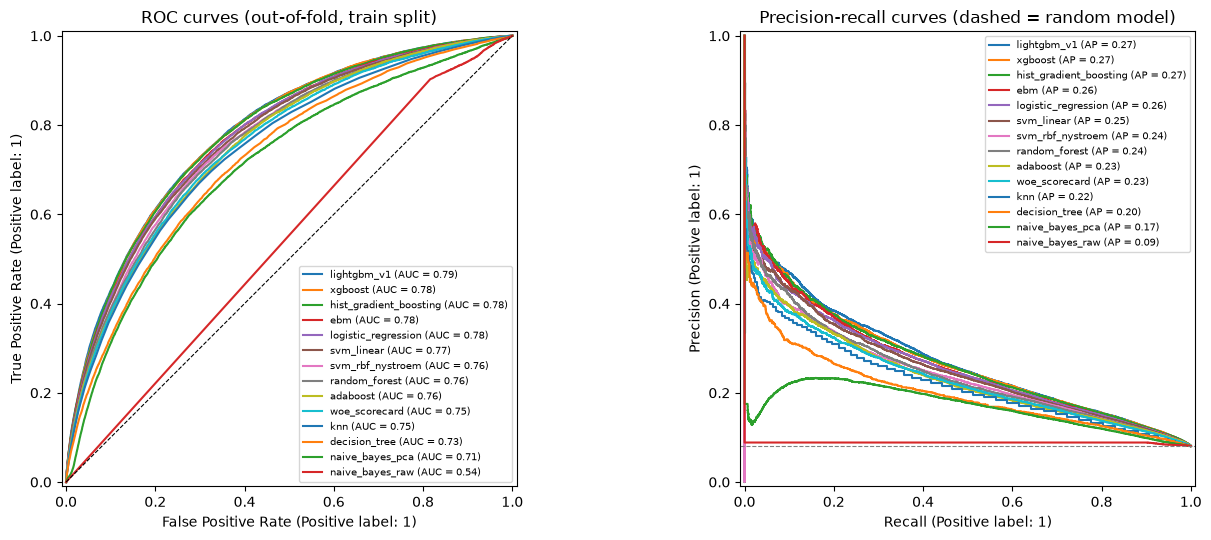

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for name in table.index:
    RocCurveDisplay.from_predictions(y, results[name].oof, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y, results[name].oof, name=name, ax=axes[1])
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set_title("ROC curves (out-of-fold, train split)")
axes[1].axhline(y.mean(), color="grey", ls="--", lw=0.8)
axes[1].set_title("Precision-recall curves (dashed = random model)")
for ax in axes:
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIG / "fig14_ladder_roc_pr.png", dpi=150, bbox_inches="tight")
print("saved reports/figures/fig14_ladder_roc_pr.png")

## Bias vs variance: the decision-tree depth curve

Trees of growing depth are trained on folds 2–5 (a 60,000-row sample, to keep it quick) and
checked on fold 1. The training score keeps rising, but the held-out score peaks and then falls.
That gap is overfitting (high variance); very shallow trees are too simple (high bias).

,train ROC-AUC,held-out ROC-AUC
depth,,
2,0.6964,0.7030
4,0.7166,0.7174
6,0.7339,0.7252
8,0.7525,0.7177
10,0.7772,0.6906
14,0.8293,0.6170
20,0.9052,0.5192


saved reports/figures/fig15_tree_depth_curve.png


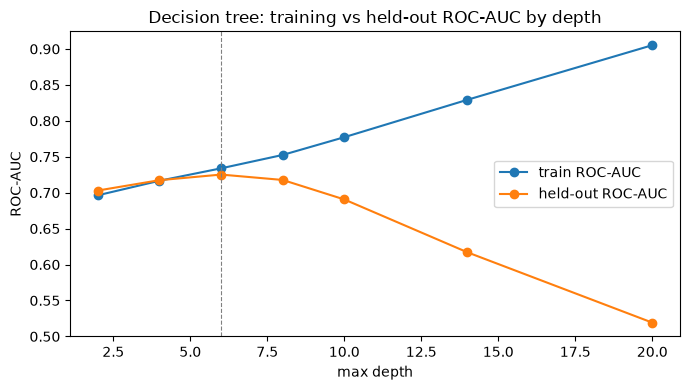

In [6]:
fit_rows = np.flatnonzero(folds != 1)
rng = np.random.default_rng(SEED)
fit_rows = rng.choice(fit_rows, size=min(60_000, len(fit_rows)), replace=False)
check_rows = np.flatnonzero(folds == 1)
curve = []
for depth in [2, 4, 6, 8, 10, 14, 20]:
    tree = baselines.decision_tree(groups, max_depth=depth, min_samples_leaf=1, seed=SEED)
    tree.fit(X.iloc[fit_rows], y[fit_rows])
    curve.append({
        "depth": depth,
        "train ROC-AUC": roc_auc_score(y[fit_rows], tree.predict_proba(X.iloc[fit_rows])[:, 1]),
        "held-out ROC-AUC": roc_auc_score(y[check_rows],
                                          tree.predict_proba(X.iloc[check_rows])[:, 1]),
    })
curve = pd.DataFrame(curve).set_index("depth").round(4)
best_depth = int(curve["held-out ROC-AUC"].idxmax())
facts["tree_best_depth"] = (best_depth, float(curve.loc[best_depth, "held-out ROC-AUC"]))
facts["tree_depth20_train_vs_heldout"] = tuple(curve.loc[20])
display(curve)

fig, ax = plt.subplots(figsize=(7, 4))
curve.plot(ax=ax, marker="o")
ax.axvline(best_depth, color="grey", ls="--", lw=0.8)
ax.set(title="Decision tree: training vs held-out ROC-AUC by depth", xlabel="max depth",
       ylabel="ROC-AUC")
fig.tight_layout()
fig.savefig(FIG / "fig15_tree_depth_curve.png", dpi=150, bbox_inches="tight")
print("saved reports/figures/fig15_tree_depth_curve.png")

## The WoE scorecard: how a bank would score

One scorecard is fitted on the whole train split. The table shows the features with the highest
information value (IV), and then the points for the top 3 features. Convention: 600 points at
good:bad odds of 50:1, and every 20 points doubles the odds. An applicant's score is the sum of
the points of their bins; more points means safer.

In [7]:
card = woe_scorecard(SEED).fit(X, y)
points = scorecard_points(card)
points.to_csv(PROJECT_ROOT / "reports" / "scorecard_points.csv", index=False)
iv = pd.Series(card.named_steps["woe"].iv_).sort_values(ascending=False)
facts["top_iv_features"] = iv.head(5).round(3).to_dict()
facts["scorecard_features_used"] = len(card.named_steps["woe"].selected_)
display(iv.head(15).round(3).rename("information value").to_frame())
for feature in card.named_steps["woe"].selected_[:3]:
    print(f"\n{feature}")
    rows = points[points["feature"] == feature][["bin", "woe", "points"]]
    print(rows.round(2).to_string(index=False))
print("\nsaved reports/scorecard_points.csv")

,information value
APP_EXT_MEAN,0.614
APP_EXT_MIN,0.467
APP_EXT_MAX,0.447
APP_EXT_SOURCE_3,0.332
APP_EXT_SOURCE_2,0.307
APP_EXT_PROD,0.275
APP_EXT_SOURCE_1,0.153
APP_ANNUITY_TO_CREDIT,0.138
BUR_MEAN_LOAN_AGE_YEARS,0.122
APP_EMPLOYED_YEARS,0.113



APP_EXT_MEAN
             bin   woe  points
  (-inf, 0.3038] -1.21   19.35
(0.3038, 0.3844] -0.65   18.99
(0.3844, 0.4395] -0.31   18.77
 (0.4395, 0.484] -0.01   18.58
 (0.484, 0.5244]  0.20   18.45
(0.5244, 0.5637]  0.43   18.31
(0.5637, 0.6024]  0.74   18.11
 (0.6024, 0.644]  0.86   18.03
 (0.644, 0.6927]  1.05   17.92
   (0.6927, inf]  1.49   17.63
         missing -0.11   18.65

APP_EXT_MIN
             bin   woe  points
  (-inf, 0.1438] -1.12    9.64
(0.1438, 0.2195] -0.53   14.33
(0.2195, 0.2822] -0.29   16.23
(0.2822, 0.3433] -0.05   18.21
(0.3433, 0.4031]  0.14   19.73
(0.4031, 0.4633]  0.39   21.66
(0.4633, 0.5227]  0.53   22.80
 (0.5227, 0.583]  0.71   24.29
 (0.583, 0.6482]  0.92   25.91
   (0.6482, inf]  1.23   28.37
         missing -0.11   17.67

APP_EXT_MAX
             bin   woe  points
  (-inf, 0.3962] -1.10   13.61
 (0.3962, 0.506] -0.56   16.07
 (0.506, 0.5691] -0.24   17.48
(0.5691, 0.6131] -0.03   18.45
(0.6131, 0.6489]  0.16   19.28
(0.6489, 0.6801]  0.31   19.99

## Why Naive Bayes failed, and how PCA fixes it

Naive Bayes assumes every feature is independent of the others. Here dozens of columns copy each
other, so raw NB counts the same evidence many times. PCA turns the features into uncorrelated
components, which is much closer to what NB assumes.

In [8]:
nb_raw = results["naive_bayes_raw"].summary["roc_auc"]
nb_pca = results["naive_bayes_pca"].summary["roc_auc"]
facts["naive_bayes_raw_vs_pca"] = (round(nb_raw, 4), round(nb_pca, 4))
print(f"Naive Bayes on raw features: {nb_raw:.4f} | on 30 PCA components: {nb_pca:.4f}")

Naive Bayes on raw features: 0.5432 | on 30 PCA components: 0.7084


## Random forest: the free out-of-bag check (optional, about 1–3 minutes)

Each tree only sees a random part of the data, so every applicant can be scored by the trees that
never saw them. This *out-of-bag* score is a built-in validation and should be close to the CV score.

In [9]:
forest = random_forest(groups, SEED, oob=True).fit(X, y)
oob_auc = roc_auc_score(y, forest.named_steps["model"].oob_decision_function_[:, 1])
cv_auc = results["random_forest"].summary["roc_auc"]
facts["random_forest_oob_vs_cv"] = (round(oob_auc, 4), round(cv_auc, 4))
print(f"Random forest: out-of-bag ROC-AUC {oob_auc:.4f} vs 5-fold CV ROC-AUC {cv_auc:.4f}")

Random forest: out-of-bag ROC-AUC 0.7631 vs 5-fold CV ROC-AUC 0.7625


## Key facts


In [10]:
for key, value in facts.items():
    print(f"{key:<30} {value}")

auc_by_model                   {'lightgbm_v1': 0.786, 'xgboost': 0.7846, 'hist_gradient_boosting': 0.7834, 'ebm': 0.7764, 'logistic_regression': 0.7756, 'svm_linear': 0.7715, 'svm_rbf_nystroem': 0.7636, 'random_forest': 0.7625, 'adaboost': 0.757, 'woe_scorecard': 0.7548, 'knn': 0.7462, 'decision_tree': 0.7252, 'naive_bayes_pca': 0.7084, 'naive_bayes_raw': 0.5432}
best_model                     ('lightgbm_v1', 0.786)
runner_up                      ('xgboost', 0.7846)
comparisons                    {'lightgbm_v1 - xgboost': 0.0014, 'lightgbm_v1 - logistic_regression': 0.0104, 'lightgbm_v1 - woe_scorecard': 0.0312}
tree_best_depth                (6, 0.7252)
tree_depth20_train_vs_heldout  (0.9052, 0.5192)
top_iv_features                {'APP_EXT_MEAN': 0.614, 'APP_EXT_MIN': 0.467, 'APP_EXT_MAX': 0.447, 'APP_EXT_SOURCE_3': 0.332, 'APP_EXT_SOURCE_2': 0.307}
scorecard_features_used        30
naive_bayes_raw_vs_pca         (0.5432, 0.7084)
random_forest_oob_vs_cv        (0.7631, 0.7625)


## Findings

- Every model was trained on the same 5 folds of the train split (184,503 applicants, 240 features), with all preprocessing and feature selection fitted inside each training fold.
- **Best model: LightGBM v1**, ROC-AUC 0.786 (95% CI 0.783 to 0.790). Runner-up: XGBoost 0.785, then HistGradientBoosting 0.783. LightGBM beats XGBoost by only +0.0014 (significant: __), so the three gradient-boosting libraries are practically tied. It is the method that matters, not the library.
- **Older ensembles:** random forest (bagging) 0.763 and AdaBoost (boosting with stumps) 0.757, both clearly behind modern gradient boosting. Random forest's out-of-bag score (0.763) matches its 5-fold CV score (0.763), so the built-in OOB check is a reliable shortcut.
- **Glass-box model:** EBM reaches 0.776 (95% CI __), only 0.0096 below the best model, while staying fully interpretable.
- **Linear models:** logistic regression 0.776 (0.772 to 0.779), only 0.0104 below LightGBM (significant: __). The engineered ratios already capture much of the non-linear signal. Linear SVM 0.772 behaves almost the same as logistic regression.
- **WoE scorecard (30 features, points table):** 0.755 (0.751 to 0.758). The price of this full transparency is 0.0312 ROC-AUC vs the best model (significant: __). EBM gives transparency at a much smaller cost (0.0096).
- **RBF SVM (Nystroem):** 0.764, below the linear SVM, so the curved kernel did not help on top of the engineered features.
- **KNN** on 20 PCA components of the top 60 features: 0.746.
- **Decision tree (depth 8):** 0.725. The depth curve peaks at depth 6 (held-out 0.725). At depth 20 the training score is 0.905 but held-out only 0.519, which is clear overfitting (high variance).
- **Naive Bayes:** raw 0.543 vs 0.708 on 30 PCA components. Part of the raw score is a measuring problem: with 240 correlated features, NB is so overconfident that 82.3% of applicants get a probability of exactly 1.0, and ROC-AUC cannot rank tied applicants. Ranked by its log-odds instead, raw NB scores 0.664 (checked in notebook 07). PCA still does better (0.708), because correlated features make NB count the same evidence several times, which distorts the ranking itself, not only the probabilities.
- **Highest information value (IV):** EXT_MEAN 0.614, EXT_MIN 0.467, EXT_MAX 0.447, EXT_SOURCE_3 0.332, EXT_SOURCE_2 0.307. All five come from the external scores. EXT_MEAN is above the usual 0.5 "suspiciously strong" level, which is expected here, because the external scores are themselves risk scores from other models.
- **Ranking:** gradient boosting > EBM ≈ logistic regression > linear SVM > RBF SVM ≈ random forest > AdaBoost ≈ scorecard > KNN > tree > NB on PCA > raw NB.